<a id="top"></a>
<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>APRENDIZADO DE MÁQUINA (CIC1205/GCC1932) - Trabalho 2</center></h1>

- Nome completo: Hélio Henrique de Souza
- [Link para vídeo](<LINK_VIDEO>)
- [Link para git](<https://github.com/HezaH/Machine_Learning>)

# Import Libs

In [1]:
import os
import time
import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, 
    median_absolute_error, mean_squared_log_error, explained_variance_score,
    confusion_matrix, classification_report, accuracy_score,
    f1_score, balanced_accuracy_score, average_precision_score
)
from pathlib import Path
from sklearn.decomposition import PCA
from IPython.display import HTML, IFrame

# Main functions

In [3]:
def show_confusion( y_true, y_pred, labels, name_fig , title="Matriz de Confusão", plot_heatmap=True, cmap="Blues", figsize=(6, 5), ):
    """
    Exibe a matriz de confusão com rótulos nas linhas (reais)
    e colunas (preditos) na ordem especificada por `labels`.

    Parâmetros
    ----------
    y_true : array-like
        Rótulos reais.
    y_pred : array-like
        Rótulos preditos.
    labels : list
        Ordem desejada das classes (ex.: ['NONE', 'WEAK', 'MODERATE', 'STRONG']).
    title : str
        Título mostrado antes da tabela / heatmap.
    plot_heatmap : bool
        Se True, desenha também um heatmap usando seaborn.
    cmap : str
        Mapa de cores para o heatmap.
    figsize : tuple
        Tamanho da figura do heatmap.
    """
    # 1. Matriz numérica
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # 2. DataFrame bonito para print
    df_cm = pd.DataFrame(
        cm,
        index=[f"REAL → {lbl}" for lbl in labels],
        columns=[f"PRED → {lbl}" for lbl in labels],
    )

    # 3. Print “cru” no console
    print(f"\n{title}")
    print(df_cm)

    # 4. Heatmap opcional
    if plot_heatmap:
        plt.figure(figsize=figsize)
        sns.heatmap(
            df_cm,
            annot=True,
            fmt="d",
            cmap=cmap,
            cbar=False,
            linewidths=0.5,
            linecolor="0.9",
        )
        plt.title(title, fontweight="bold")
        plt.ylabel("Classe Real")
        plt.xlabel("Classe Predita")
        plt.tight_layout()
        try:
            plt.savefig(name_fig, dpi=300, bbox_inches='tight')
        except:
            plt.show()
        plt.close()

def predict_ordinal(df, classifiers, features):
    preds = []
    for clf in classifiers:
        # Supondo que você queira as probabilidades da classe 1 para cada limiar
        pred = clf.predict_proba(df[features])[:, 1]
        preds.append(pred)
    
    preds = np.array(preds)  # shape: (n_threshold, n_samples)
    # Calcula as probabilidades das k classes:
    # Para a primeira classe:
    prob_class0 = 1 - preds[0]
    prob_classes = [prob_class0]
    
    # Para as classes intermediárias:
    for i in range(1, preds.shape[0]):
        # A probabilidade da classe i é a diferença entre a probabilidade da classe i-1 e a classe i
        #preds[i-1] = probabilidade da classe i-1
        #preds[i] = probabilidade da classe i
        prob = preds[i-1] - preds[i]
        prob_classes.append(prob)
    
    # Para a última classe:
    prob_class_last = preds[-1]
    prob_classes.append(prob_class_last)
    
    # Transforma em array: shape (k, n_samples)
    prob_classes = np.array(prob_classes)
    
    # Predição final: índice da classe com maior probabilidade
    pred_idx = np.argmax(prob_classes, axis=0)
    
    # Cria um dicionário inverso para mapear o código ordinal para a categoria
    mapping_inv = {v: k for k, v in choices.items()}
    pred_labels = [mapping_inv[i] for i in pred_idx]
    return pred_labels, prob_classes

def change_cathegory(df, choices):
    """
    Transforma a variável 'target' em uma classificação ordinal:
      - Cria a coluna "categoria", baseada em condições do valor contínuo;
      - Mapeia para "cat_code" usando o dicionário de escolhas, mas apenas com os rótulos presentes no dataframe;
      - Cria as colunas binárias T_1, T_2, ... T_(k-1), onde k é o número de categorias observadas.
    """
    # Definir as condições para os intervalos
    conditions = [
        (df["target"] == 0),
        ((df["target"] > 0) & (df["target"] <= 5)),
        ((df["target"] > 5) & (df["target"] <= 25)),
        (df["target"] > 25)
        # ((df["target"] > 25) & (df["target"] <= 50)),
        # (df["target"] > 50)
    ]
    
    # Aplica o np.select usando todas as categorias do dicionário base
    df["categoria"] = np.select(conditions, list(choices.keys()), default=np.nan)
    
    # Filtra as categorias que de fato aparecem no dataframe, mantendo a ordem definida em choices
    present_cats = [cat for cat in choices.keys() if (df["categoria"] == cat).any()]
    
    # Cria um novo mapeamento somente para as categorias presentes
    new_choices = {cat: i for i, cat in enumerate(present_cats)}
    
    # Mapeia os rótulos que foram de fato usados para códigos numéricos
    df["cat_code"] = df["categoria"].map(new_choices)
    
    # Número de colunas binárias a serem criadas (k - 1), onde k é o número de categorias presentes
    n = len(new_choices) - 1  
    for i in range(n):
        df[f'T_{i+1}'] = (df["cat_code"] > i).astype(int)
        
    return df, new_choices


# (1) Enngenharia de Features

Importando o modelo, definindo as colunas 

In [34]:
# Inicia a medição do tempo
start_time = time.time()
out_dir = Path("figures")
out_dir.mkdir(exist_ok=True)

# Carrega o dataset
try:
    df_diamonds = pd.read_csv('diamonds.csv')
except FileNotFoundError:
    out_dir = os.path.dirname(os.path.realpath(__file__))
    current_dir = out_dir
    df_diamonds = pd.read_csv(os.path.join(current_dir, 'diamonds.csv'))

Tratamento dos dados

In [35]:

# Para treinar um modelo que prediz z, selecione apenas os registros com z > 0 (valores válidos)
df_diamonds = df_diamonds[~df_diamonds.index.isin(df_diamonds[df_diamonds[['x', 'y', 'z']].eq(0).sum(axis=1) >= 2].index)].copy()

df_valid = df_diamonds[df_diamonds['z'] > 0].copy()
df_invalid = df_diamonds[df_diamonds['z'] == 0].copy()


Pipeline de predição de z vazios

In [36]:

# Defina as features originais que queremos usar. Atenção: não use features derivadas que contenham z (como volume).
# Neste exemplo, utilizaremos as medidas originais e informações categóricas.
features = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y']
target = 'z'

X = df_valid[features]
y = df_valid[target]

# Divide os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Defina os nomes das colunas numéricas e categóricas
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y']
categorical_preproc = ['cut', 'color', 'clarity']

# Cria o pré-processador: escalona os numéricos e codifica as categorias (usando OneHotEncoder para evitar assumir ordens pré-definidas)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(), categorical_preproc )
])

# Instancia o modelo. Aqui usamos regressão linear simples; você pode testar outros modelos, como RandomForestRegressor.
model = LinearRegression()

# Monta o pipeline de pré-processamento e modelo
pipeline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# Treina o pipeline
pipeline_model.fit(X_train, y_train)

# Faz a predição no conjunto de teste e avalia o desempenho
y_pred = pipeline_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE para predição de z: {rmse:.4f}")


RMSE para predição de z: 0.2764


Criação de correlacoes

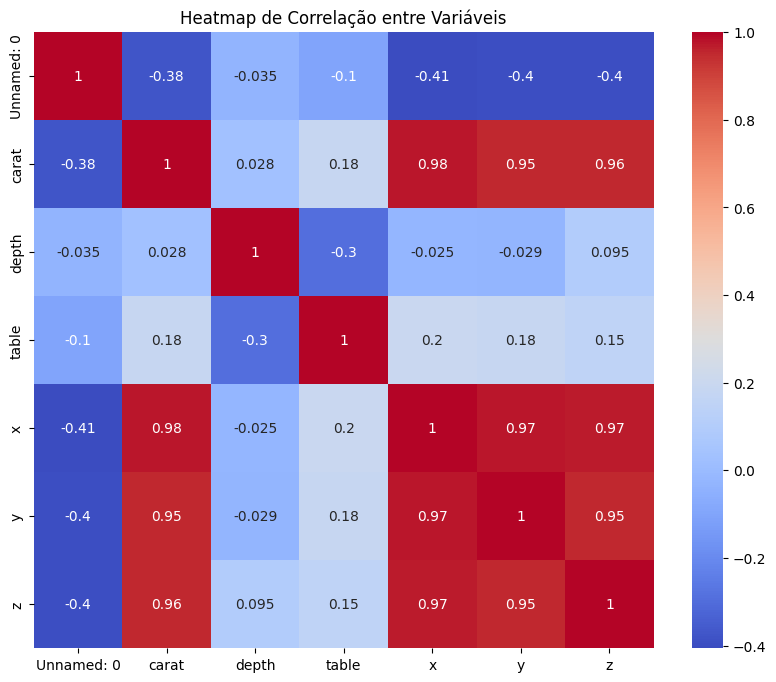

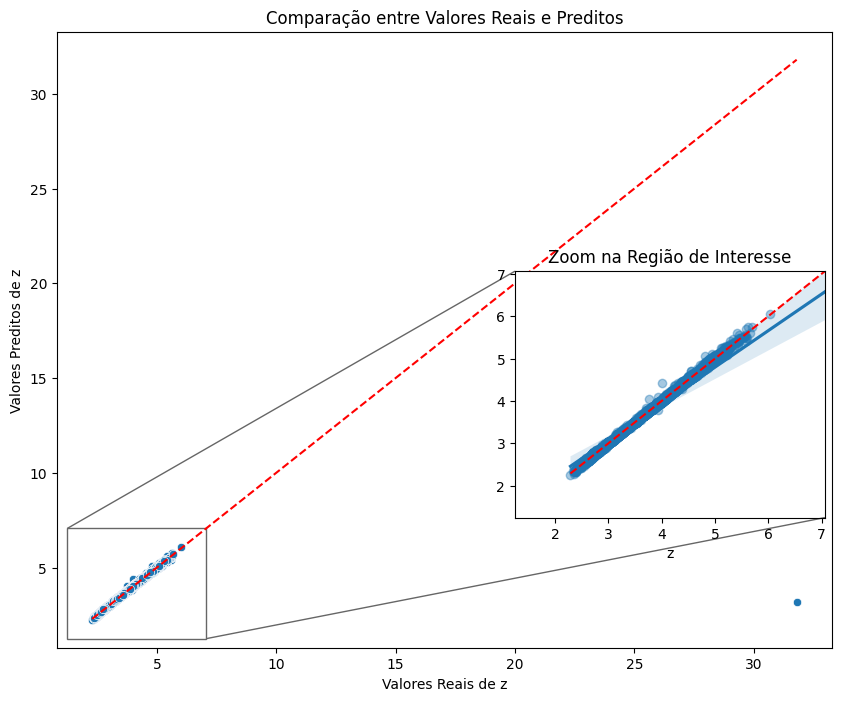

In [37]:

# Gráfico 2: Heatmap de Correlação entre as features numéricas
cols = list(df_diamonds.columns)
# Definir as features categóricas e a variável alvo

target_column = 'price'
# Para o heatmap, iremos usar apenas as colunas numéricas (excluindo as categóricas e a target)
numeric_features = [col for col in cols if col not in categorical_preproc + [target_column]]
corr_matrix = df_diamonds[numeric_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Heatmap de Correlação entre Variáveis")
try:
    plt.savefig(os.path.join(out_dir, "figures", "Heatmap.png"), dpi=300, bbox_inches='tight')
except:
    plt.show()
plt.close()

# Gráfico 1: Relação entre Volume e Preço
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred)
ax.set_title("Comparação entre Valores Reais e Preditos")
ax.set_xlabel("Valores Reais de z")
ax.set_ylabel("Valores Preditos de z")
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Linha de Igualdade')
# Cria um inset (subgráfico) com zoom na região desejada
axins = inset_axes(ax, width="40%", height="40%", loc='lower right',
                   bbox_to_anchor=(0, 0.2, 1, 1),
                   bbox_transform=ax.transAxes)

sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.4}, ax=axins)
axins.set_xlim(min(y_test.min(), y_pred.min()) - 1, min(y_test.max(), y_pred.max()) + 1)         # Limita o eixo x do inset
axins.set_ylim(min(y_test.min(), y_pred.min()) - 1, min(y_test.max(), y_pred.max()) + 1)       # Limita o eixo y do inset
axins.set_title("Zoom na Região de Interesse")
axins.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Linha de Igualdade')
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4")
try:
    plt.savefig(os.path.join(out_dir, "figures", "value_price.png"), dpi=300, bbox_inches='tight')
except:
    plt.show()
plt.close()  # Fecha o gráfico atual



Previsão de z vazios

In [38]:
# Se houver registros com z igual a 0, prevê os valores de z para esses registros.
if not df_invalid.empty:
    X_invalid = df_invalid[features]
    z_pred = pipeline_model.predict(X_invalid)
    
    # Atualiza a coluna z dos registros com z = 0 no DataFrame original
    df_diamonds.loc[df_diamonds['z'] == 0, 'z'] = abs(z_pred)
    print("Valores de z imputados para registros com z == 0.")

# Visualiza as primeiras linhas do DataFrame atualizado
print(df_diamonds.head())

Valores de z imputados para registros com z == 0.
   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  


Criação de features

In [39]:

# Engenharia de features: Adiciona volume e outras derivadas
df_diamonds['volume'] = df_diamonds['x'] * df_diamonds['y'] * df_diamonds['z']

## Calcula quartis
Q1 = df_diamonds['volume'].quantile(0.25)  # Primeiro quartil (25%)
Q3 = df_diamonds['volume'].quantile(0.75)  # Terceiro quartil (75%)
IQR = Q3 - Q1  # Intervalo interquartil

# Define limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtra valores dentro do intervalo aceitável
df_diamonds = df_diamonds[(df_diamonds['volume'] >= limite_inferior) & (df_diamonds['volume'] <= limite_superior)]

df_diamonds["price_per_carat"] = df_diamonds["price"] / df_diamonds["carat"]
df_diamonds["price_per_volume"] = df_diamonds["price"] / df_diamonds["volume"]

df_diamonds["ratio_x_y"] = df_diamonds["x"] / df_diamonds["y"]
df_diamonds["ratio_x_z"] = df_diamonds["x"] / df_diamonds["z"]
df_diamonds["ratio_y_z"] = df_diamonds["y"] / df_diamonds["z"]

df_diamonds["log_price"] = np.log(df_diamonds["price"])

# Remove a coluna indesejada (se existir) e reseta o índice
if 'Unnamed: 0' in df_diamonds.columns:
    df_diamonds = df_diamonds.drop(columns='Unnamed: 0').reset_index(drop=True)

Geração de representações graficas

In [ ]:

# Criando o gráfico interativo
fig = px.scatter(df_diamonds, x="volume", y="price", color="cut",
                 title="Relação entre Volume e Preço do Diamante")

# Exportando para HTML
try:
    fig.write_html(os.path.join(out_dir, "figures", "diamantes_interativo.html"))
except:
    fig.show()

In [ ]:
# -----------------------------------------------------------
# 1. PREÇO  ×  PRICE-PER-CARAT   (cores = CUT)
# -----------------------------------------------------------
fig = px.scatter(
    df_diamonds,
    x="price_per_carat",
    y="price",
    color="cut",
    hover_data=["carat", "color", "clarity"],
    title="Preço vs. Preço por Quilate (CUT)",
    labels={
        "price_per_carat": "Preço / Quilate",
        "price": "price",
        "cut": "Cut"
    },
)
fig.update_traces(marker=dict(opacity=0.65, line=dict(width=0.3, color="white")))
try:
    fig.write_html(os.path.join(out_dir, "figures", "price_vs_price_per_carat_cut.html"), include_plotlyjs="cdn")
except:
    fig.show()

In [ ]:


# -----------------------------------------------------------
# 2. PREÇO  ×  PRICE-PER-VOLUME  (cores = CLARITY)
# -----------------------------------------------------------
fig_volume = px.scatter(
    df_diamonds,
    x="price_per_volume",
    y="price",
    color="clarity",
    hover_data=["volume", "color", "cut"],
    title="Preço vs. Preço por Volume (CLARITY)",
    labels={
        "price_per_volume": "Preço / Volume",
        "price": "price",
        "clarity": "Clarity"
    },
)
fig_volume.update_traces(marker=dict(opacity=0.65, line=dict(width=0.3, color="white")))
try:
    fig_volume.write_html(os.path.join(out_dir, "figures", "price_vs_price_per_volume_clarity.html"), include_plotlyjs="cdn")
except:
    fig_volume.show()


In [ ]:

# -----------------------------------------------------------
# 3. EXTRA (opcional): RELAÇÃO ENTRE RÁCIOS DE LADOS E PREÇO
# -----------------------------------------------------------
fig_ratio = px.scatter(
    df_diamonds,
    x="ratio_x_y",
    y="price",
    color="color",
    hover_data=["ratio_x_z", "ratio_y_z", "cut", "clarity"],
    title="Preço vs. Proporção x/y (COLOR)",
    labels={
        "ratio_x_y": "x / y",
        "price": "price",
        "color": "Color"
    },
)
fig_ratio.update_traces(marker=dict(opacity=0.65, line=dict(width=0.3, color="white")))
try:
    fig_ratio.write_html(os.path.join(out_dir, "figures", "price_vs_ratio_xy_color.html"), include_plotlyjs="cdn")
except:
    fig_ratio.show()

Segunda previsão, com novas features:

In [40]:

# Separando as variáveis preditoras e a variável alvo para modelagem
X = df_diamonds.drop(target_column, axis=1)
y = df_diamonds[target_column]

# Divide os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Cria o pré-processador com codificação ordinal
# Define as ordens para as variáveis categóricas
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Como X não possui a coluna target, definimos as features numéricas para o pré-processador:

numeric_preproc = [col for col in X.columns if col not in categorical_preproc]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_preproc),
    ('cat', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), categorical_preproc)
])

# Instancia o modelo KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=5)

# Monta o pipeline (pré-processamento + modelo)
pipeline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# Treina o pipeline usando os dados de treino
pipeline_model.fit(X_train, y_train)

# Faz a predição no conjunto de teste
y_pred = pipeline_model.predict(X_test)




Metricas de avaliação

In [42]:
# Calcula as métricas de avaliação
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
median_ae = median_absolute_error(y_test, y_pred)
msle = mean_squared_log_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
n = len(y_test)
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("KNeighborsRegressor (n_neighbors=5)")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Median Absolute Error: {median_ae:.4f}")
print(f"MSLE: {msle:.4f}")
print(f"Explained Variance Score: {evs:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")
print(f"MAPE: {mape:.2f}%")

# Finaliza a medição do tempo
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTempo total de processamento: {elapsed_time:.2f} segundos")

KNeighborsRegressor (n_neighbors=5)
RMSE: 333.7172
R²: 0.9910
MAE: 194.6338
Median Absolute Error: 95.0000
MSLE: 0.0076
Explained Variance Score: 0.9910
Adjusted R²: 0.9910
MAPE: 6.30%

Tempo total de processamento: 21.08 segundos


# (2) Classificação Ordinal Multi-classes

In [ ]:
# Inicia a medição do tempo
start_time = time.time()

Lendo o arquivo

In [52]:
try:
    # Load the dataset from the current directory
    with open('A652.pickle', 'rb') as f:
        (X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f)
except FileNotFoundError:
    current_dir = os.path.join(os.path.dirname(os.path.realpath(__file__)), 'A652.pickle')

    f = open(current_dir, 'rb')
    (X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f) 

print(f"Shapes: {X_train.shape}, {X_test.shape}, {X_val.shape}")

Shapes: (10012, 24), (9582, 24), (2506, 24)


Aplicando a transformacao

In [53]:

target = 'target'
scoring_type = 'accuracy'  # ou 'f1', 'precision', 'recall'

# Converte os arrays para DataFrames: concatena as features e o target
df_train = pd.concat([
    pd.DataFrame(X_train),
    pd.Series(y_train.ravel(), name=target)
], axis=1).reset_index(drop=True)

df_val = pd.concat([
    pd.DataFrame(X_val),
    pd.Series(y_val.ravel(), name=target)
], axis=1).reset_index(drop=True)

df_test = pd.concat([
    pd.DataFrame(X_test),
    pd.Series(y_test.ravel(), name=target)
], axis=1).reset_index(drop=True)

# Dicionário base com a ordem desejada
choices = {"NONE": 0, "WEAK": 1, "MODERATE": 2, "STRONG": 3}#, "EXTREME": 4}

print(f"Categorias: {choices.keys()}")

# Aplica a transformação em cada DataFrame
df_train, new_choices_train = change_cathegory(df_train, choices)
df_val, new_choices_val   = change_cathegory(df_val, choices)
df_test, new_choices_test  = change_cathegory(df_test, choices)

Categorias: dict_keys(['NONE', 'WEAK', 'MODERATE', 'STRONG'])


Definição de features

In [54]:
# Define as features para os modelos: remove as colunas derivadas do target
n_threshold = len(new_choices_train) - 1  # k - 1, onde k é o número de categorias presentes
exclude_cols = [target, "categoria", "cat_code"] + [f'T_{i+1}' for i in range(n_threshold)]
features = [col for col in df_train.columns if col not in exclude_cols]

Modelo Ordinal

== Treinamento do Modelo Ordinal ==
Treinando modelo para T_1, equiparado a 'NONE'
Treinando modelo para T_2, equiparado a 'WEAK'
Treinando modelo para T_3, equiparado a 'MODERATE'
== Modelo Ordinal ==

Matriz de Confusão – Modelo Ordinal
                 PRED → NONE  PRED → WEAK  PRED → MODERATE  PRED → STRONG
REAL → NONE             8653           96               17              3
REAL → WEAK              481          251               25              0
REAL → MODERATE           26           21                3              0
REAL → STRONG              2            3                0              1


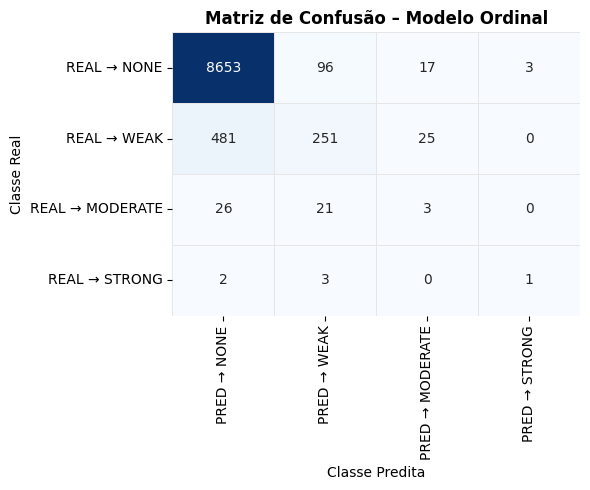


Classification Report (Ordinal):
              precision    recall  f1-score   support

        NONE       0.94      0.99      0.97      8769
        WEAK       0.68      0.33      0.45       757
    MODERATE       0.07      0.06      0.06        50
      STRONG       0.25      0.17      0.20         6

    accuracy                           0.93      9582
   macro avg       0.48      0.39      0.42      9582
weighted avg       0.92      0.93      0.92      9582



In [55]:

# ------------------------------------------------------------------
# ORDEM CANÔNICA DAS CLASSES
# ------------------------------------------------------------------
label_order  = list(choices.keys())# ['NONE','WEAK','MODERATE','STRONG']
try:
    out_dir = os.path.dirname(os.path.realpath(__file__))
except: 
    our_dir = os.getcwd()
# ------------------------------------------------------------------
# MODELO ORDINAL
# ------------------------------------------------------------------
ordinal_classifiers = []
print("== Treinamento do Modelo Ordinal ==")
for i in range(1, n_threshold + 1):
    clf = GradientBoostingClassifier(random_state=42)
    print(f"Treinando modelo para T_{i}, equiparado a '{label_order[i-1]}'")
    clf.fit(df_train[features], df_train[f'T_{i}'])
    ordinal_classifiers.append(clf)

ord_pred_labels, ord_pred_numbers = predict_ordinal(df_test, ordinal_classifiers, features)

print("== Modelo Ordinal ==")
show_confusion( df_test["categoria"], ord_pred_labels, name_fig = os.path.join(out_dir, "figures", "confusion_matrix_ordinal.png"), labels=label_order, title="Matriz de Confusão – Modelo Ordinal", )
print("\nClassification Report (Ordinal):")
print(classification_report(df_test["categoria"], ord_pred_labels,labels= label_order,target_names= label_order,zero_division=0))


Modelo Nominal


== Treinamento do Modelo Nominal ==
== Modelo Nominal ==

Matriz de Confusão – Modelo Nominal
                 PRED → NONE  PRED → WEAK  PRED → MODERATE  PRED → STRONG
REAL → NONE             8678           86                2              3
REAL → WEAK              507          234               16              0
REAL → MODERATE           25           23                2              0
REAL → STRONG              3            2                0              1


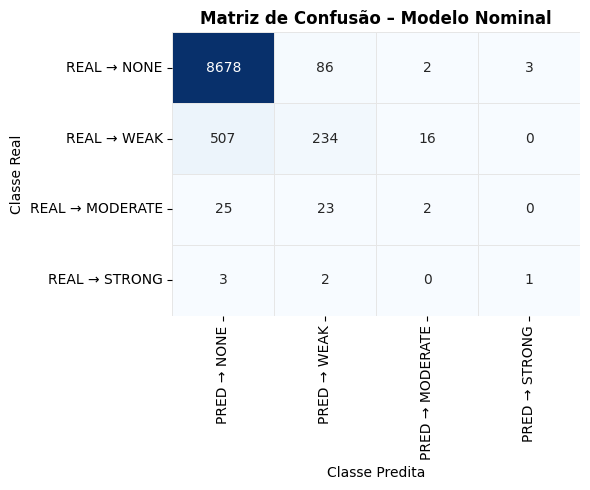


Classification Report (Nominal):
              precision    recall  f1-score   support

        NONE       0.94      0.99      0.97      8769
        WEAK       0.68      0.31      0.42       757
    MODERATE       0.10      0.04      0.06        50
      STRONG       0.25      0.17      0.20         6

    accuracy                           0.93      9582
   macro avg       0.49      0.38      0.41      9582
weighted avg       0.92      0.93      0.92      9582

Execution time: 41.41 seconds


In [56]:

# ------------------------------------------------------------------
# MODELO NOMINAL
# ------------------------------------------------------------------
print("\n== Treinamento do Modelo Nominal ==")
le = LabelEncoder()
df_train["cat_nominal"] = le.fit_transform(df_train["categoria"])
df_val["cat_nominal"]   = le.transform(df_val["categoria"])
df_test["cat_nominal"]  = le.transform(df_test["categoria"])

nominal_clf = GradientBoostingClassifier(random_state=42).fit(df_train[features], df_train["cat_nominal"])
nom_pred_labels = le.inverse_transform(nominal_clf.predict(df_test[features]))

print("== Modelo Nominal ==")
show_confusion(df_test["categoria"], nom_pred_labels, name_fig = os.path.join(out_dir, "figures", "confusion_matrix_norminal.png"), labels=label_order, title="Matriz de Confusão – Modelo Nominal", )
print("\nClassification Report (Nominal):")
print(classification_report( df_test["categoria"], nom_pred_labels, labels = label_order, target_names= label_order, zero_division=0))


# Tempo total de execução
end_time = time.time()
print(f"Execution time: {end_time - start_time:.2f} seconds")


# (4)  Redução de dimensionalidade

In [4]:
# Start time measurement
start_time = time.time()

Lendo o arquivo

In [5]:
try:
    # Load the dataset from the current directory
    with open('A652.pickle', 'rb') as f:
        (X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f)
except FileNotFoundError:
    current_dir = os.path.join(os.path.dirname(os.path.realpath(__file__)), 'A652.pickle')

    f = open(current_dir, 'rb')
    (X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f) 

print(f"Shapes: {X_train.shape}, {X_test.shape}, {X_val.shape}")


Shapes: (10012, 24), (9582, 24), (2506, 24)


Aplicando a tranformação

In [6]:

target = 'target'

# Converte os arrays para DataFrames: concatena as features e o target
df_train = pd.concat([
    pd.DataFrame(X_train),
    pd.Series(y_train.ravel(), name=target)
], axis=1).reset_index(drop=True)

df_val = pd.concat([
    pd.DataFrame(X_val),
    pd.Series(y_val.ravel(), name=target)
], axis=1).reset_index(drop=True)

df_test = pd.concat([
    pd.DataFrame(X_test),
    pd.Series(y_test.ravel(), name=target)
], axis=1).reset_index(drop=True)

# Dicionário base com a ordem desejada para o target
choices = {"NONE": 0, "WEAK": 1, "MODERATE": 2, "STRONG": 3}
label_order  = list(choices.keys())# ['NONE','WEAK','MODERATE','STRONG']
print(f"Categorias: {choices.keys()}")

# Aplica a transformação em cada DataFrame (gera também o mapeamento dinâmico new_choices)
df_train, new_choices_train = change_cathegory(df_train, choices)
df_val, new_choices_val   = change_cathegory(df_val, choices)
df_test, new_choices_test = change_cathegory(df_test, choices)

Categorias: dict_keys(['NONE', 'WEAK', 'MODERATE', 'STRONG'])


Definicao de feature

In [7]:
# Define as features para os modelos: remove as colunas derivadas do target
n_threshold = len(new_choices_train) - 1  # k - 1, onde k é o número de categorias presentes
exclude_cols = [target, "categoria", "cat_code"] + [f'T_{i+1}' for i in range(n_threshold)]
features = [col for col in df_train.columns if col not in exclude_cols]
print(f"Total de features originais usadas: {len(features)}")

Total de features originais usadas: 24


Hiperparametros

In [8]:
# -------------  hiper-parâmetros --------------------------
k_candidates  = range(2, min(20, len(features)) + 1)  # 2 … 20  (ou 2 … |features|)
metric_focus  = "macro_f1"      # métrica que decide o “winner”
verbose       = True

Target nominal

In [9]:
# =========================================================
# 1.  TARGET NOMINAL  →  números
# =========================================================
le = LabelEncoder()
df_train["cat_nominal"] = le.fit_transform(df_train["categoria"])
df_val  ["cat_nominal"] = le.transform(df_val ["categoria"])
classes_int  = np.arange(len(le.classes_))          # [0, 1, 2, 3]

Aplicacao do PCA

In [10]:

# =========================================================
# 2.  LOOP SOBRE k  (PCA)  +  MÉTRICAS ROBUSTAS
# =========================================================
results = {}
best_k  = None
best_score = -np.inf

for k in k_candidates:
    # ---- 2.1 PCA ----------------------------------------
    pca = PCA(n_components=k, random_state=42)
    X_train_pca = pca.fit_transform(df_train[features])
    X_val_pca   = pca.transform(df_val[features])

    # ---- 2.2 Modelo -------------------------------------
    clf = GradientBoostingClassifier(random_state=42)
    clf.fit(X_train_pca, df_train["cat_nominal"])

    # ---- 2.3 Predições & Probabilidades -----------------
    y_val_pred      = clf.predict(X_val_pca)
    y_val_probas    = clf.predict_proba(X_val_pca)

    # ---- 2.4 Métricas “amigas da minoria” ---------------
    macro_f1  = f1_score(
        df_val["cat_nominal"], y_val_pred, average="macro", zero_division=0
    )
    bal_acc   = balanced_accuracy_score(df_val["cat_nominal"], y_val_pred)

    # AUPRC macro (Precisão-Recall) – sensível ao desequilíbrio
    y_val_bin     = label_binarize(df_val["cat_nominal"], classes=classes_int)
    auprc_macro   = average_precision_score(
        y_val_bin, y_val_probas, average="macro"
    )

    results[k] = {
        "macro_f1":  macro_f1,
        "bal_acc":   bal_acc,
        "auprc":     auprc_macro,
    }

    # ---- 2.5 Verbose ------------------------------------
    if verbose:
        print(
            f"k={k:2d} | F1_macro={macro_f1:.4f} | "
            f"BalAcc={bal_acc:.4f} | AUPRC={auprc_macro:.4f}"
        )

    # ---- 2.6 Escolhe o melhor conforme “metric_focus” ----
    if results[k][metric_focus] > best_score + 1e-6:
        best_score = results[k][metric_focus]
        best_k     = k
        best_clf   = clf            # guarda também o modelo vencedor
        best_pca   = pca


k= 2 | F1_macro=0.2528 | BalAcc=0.2566 | AUPRC=0.3088
k= 3 | F1_macro=0.2398 | BalAcc=0.2500 | AUPRC=0.2866
k= 4 | F1_macro=0.2877 | BalAcc=0.2783 | AUPRC=0.3249
k= 5 | F1_macro=0.3460 | BalAcc=0.3386 | AUPRC=0.3568
k= 6 | F1_macro=0.3426 | BalAcc=0.3387 | AUPRC=0.3498
k= 7 | F1_macro=0.3336 | BalAcc=0.3227 | AUPRC=0.3424
k= 8 | F1_macro=0.3242 | BalAcc=0.3132 | AUPRC=0.3488
k= 9 | F1_macro=0.3315 | BalAcc=0.3188 | AUPRC=0.3497
k=10 | F1_macro=0.3471 | BalAcc=0.3266 | AUPRC=0.3939
k=11 | F1_macro=0.3469 | BalAcc=0.3275 | AUPRC=0.3775
k=12 | F1_macro=0.3450 | BalAcc=0.3253 | AUPRC=0.3887
k=13 | F1_macro=0.3442 | BalAcc=0.3250 | AUPRC=0.3792
k=14 | F1_macro=0.3585 | BalAcc=0.3571 | AUPRC=0.3856
k=15 | F1_macro=0.3759 | BalAcc=0.3664 | AUPRC=0.4277
k=16 | F1_macro=0.4685 | BalAcc=0.6129 | AUPRC=0.4523
k=17 | F1_macro=0.4776 | BalAcc=0.6176 | AUPRC=0.4598
k=18 | F1_macro=0.5203 | BalAcc=0.6588 | AUPRC=0.5139
k=19 | F1_macro=0.3722 | BalAcc=0.3649 | AUPRC=0.3974
k=20 | F1_macro=0.3716 | Bal

Resultados

In [11]:
# =========================================================
# 3.  RESUMO DOS RESULTADOS
# =========================================================
print("\n===== RESUMO POR k =====")
res_df = (
    pd.DataFrame(results)
    .T.sort_index()
    .round(4)
    .rename_axis("k")
)
print(res_df)

print(f"\nMelhor k (por {metric_focus})  →  {best_k}  "
      f"| {metric_focus} = {best_score:.4f}")



===== RESUMO POR k =====
    macro_f1  bal_acc   auprc
k                            
2     0.2528   0.2566  0.3088
3     0.2398   0.2500  0.2866
4     0.2877   0.2783  0.3249
5     0.3460   0.3386  0.3568
6     0.3426   0.3387  0.3498
7     0.3336   0.3227  0.3424
8     0.3242   0.3132  0.3488
9     0.3315   0.3188  0.3497
10    0.3471   0.3266  0.3939
11    0.3469   0.3275  0.3775
12    0.3450   0.3253  0.3887
13    0.3442   0.3250  0.3792
14    0.3585   0.3571  0.3856
15    0.3759   0.3664  0.4277
16    0.4685   0.6129  0.4523
17    0.4776   0.6176  0.4598
18    0.5203   0.6588  0.5139
19    0.3722   0.3649  0.3974
20    0.3716   0.3649  0.3923

Melhor k (por macro_f1)  →  18  | macro_f1 = 0.5203


Melhor modelo

In [12]:

# =========================================================
# 4.  RELATÓRIO DETALHADO DO MELHOR MODELO
# =========================================================
print("\n=== Classification report no conjunto de VALIDAÇÃO ===")
y_val_best_pred = best_clf.predict(best_pca.transform(df_val[features]))
print(
    classification_report(
        df_val["cat_nominal"],
        y_val_best_pred,
        target_names=label_order,
        zero_division=0,
    )
)

fig = px.line(
    res_df.reset_index(),          # vira coluna "k"
    x="k",
    y=res_df.columns,              # ['macro_f1','bal_acc','auprc']
    markers=True,
    title="Evolução das Métricas vs. Número de Componentes (k)",
    labels={
        "k": "Componentes (k)",
        "value": "Score",
        "variable": "Métrica",     # vira legenda
    },
)
try:
    fig.write_html(os.path.join(out_dir, "figures", "metricas_vs_k.html"), include_plotlyjs="cdn")  # arquivo interativo
except:
    fig.show()



=== Classification report no conjunto de VALIDAÇÃO ===
              precision    recall  f1-score   support

        NONE       0.13      0.33      0.19         6
        WEAK       0.94      0.98      0.96      2277
    MODERATE       0.33      1.00      0.50         1
      STRONG       0.66      0.32      0.43       222

    accuracy                           0.92      2506
   macro avg       0.52      0.66      0.52      2506
weighted avg       0.91      0.92      0.91      2506



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

D2

In [13]:

# ----------------------------
# Criação do conjunto D2 utilizando o melhor k
# ----------------------------
pca_final = PCA(n_components=best_k)
X_train_pca_final = pca_final.fit_transform(df_train[features])
X_val_pca_final   = pca_final.transform(df_val[features])
X_test_pca_final  = pca_final.transform(df_test[features])

# Agora D2 consiste nos dataframes originais transformados via PCA
# Você pode criar DataFrames para facilitação, se necessário:
df_train_pca = pd.DataFrame(X_train_pca_final, columns=[f"PC{i+1}" for i in range(best_k)])
df_val_pca   = pd.DataFrame(X_val_pca_final, columns=[f"PC{i+1}" for i in range(best_k)])
df_test_pca  = pd.DataFrame(X_test_pca_final, columns=[f"PC{i+1}" for i in range(best_k)])

D1

== Treinamento do Modelo Nominal sobre D1 (original) ==

Matriz de Confusão (D1)
                 PRED → NONE  PRED → WEAK  PRED → MODERATE  PRED → STRONG
REAL → NONE             8678           86                2              3
REAL → WEAK              507          234               16              0
REAL → MODERATE           25           23                2              0
REAL → STRONG              3            2                0              1


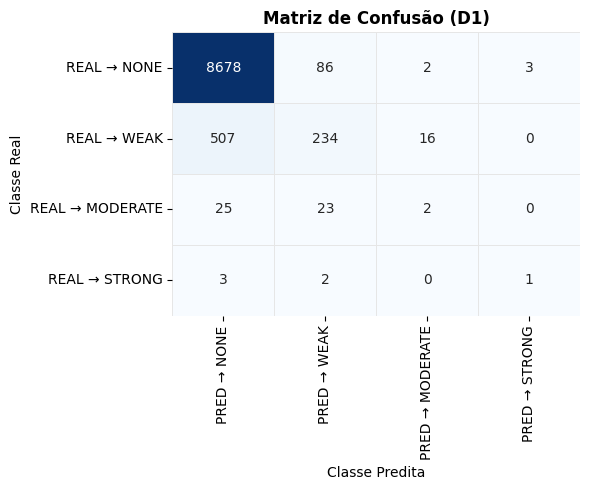


Classification Report (D1):
              precision    recall  f1-score   support

        NONE       0.94      0.99      0.97      8769
        WEAK       0.68      0.31      0.42       757
    MODERATE       0.10      0.04      0.06        50
      STRONG       0.25      0.17      0.20         6

    accuracy                           0.93      9582
   macro avg       0.49      0.38      0.41      9582
weighted avg       0.92      0.93      0.92      9582



In [17]:
# ----------------------------
# Ajusta dois modelos: um sobre D1 (conjunto original) e outro sobre D2 (dados reduzidos via PCA)
# ----------------------------
print("== Treinamento do Modelo Nominal sobre D1 (original) ==")
clf_D1 = GradientBoostingClassifier(random_state=42)
clf_D1.fit(df_train[features], df_train["cat_nominal"])
pred_D1 = clf_D1.predict(df_test[features])
pred_D1_labels = le.inverse_transform(pred_D1)

out_dir = Path("figures")
show_confusion(df_test["categoria"], pred_D1_labels, name_fig = os.path.join(out_dir, "figures", "confusion_matrix_d1.png"), labels=label_order, title="Matriz de Confusão (D1)" )
print("\nClassification Report (D1):")
print(classification_report(df_test["categoria"], pred_D1_labels, labels=label_order))


Resultados comparativos


== Treinamento do Modelo Nominal sobre D2 (PCA) ==

Matriz de Confusão (D2)
                 PRED → NONE  PRED → WEAK  PRED → MODERATE  PRED → STRONG
REAL → NONE             8700           52               14              3
REAL → WEAK              626          118               13              0
REAL → MODERATE           34           13                3              0
REAL → STRONG              4            2                0              0


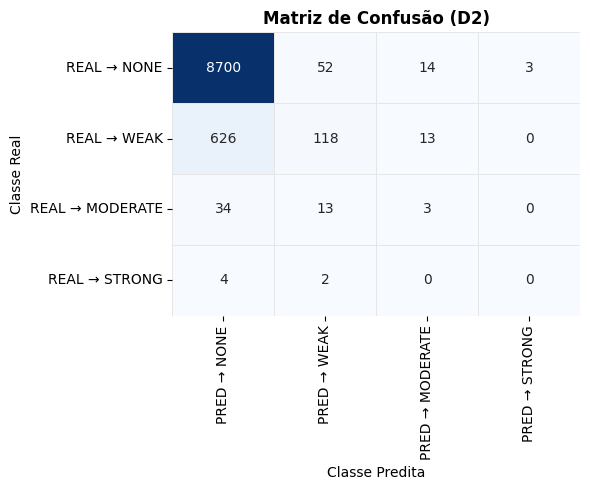


Classification Report (D2):
              precision    recall  f1-score   support

        NONE       0.93      0.99      0.96      8769
        WEAK       0.64      0.16      0.25       757
    MODERATE       0.10      0.06      0.07        50
      STRONG       0.00      0.00      0.00         6

    accuracy                           0.92      9582
   macro avg       0.42      0.30      0.32      9582
weighted avg       0.90      0.92      0.90      9582

Execution time: 1220.68 seconds


In [18]:


print("\n== Treinamento do Modelo Nominal sobre D2 (PCA) ==")
clf_D2 = GradientBoostingClassifier(random_state=42)
clf_D2.fit(X_train_pca_final, df_train["cat_nominal"])
pred_D2 = clf_D2.predict(X_test_pca_final)
pred_D2_labels = le.inverse_transform(pred_D2)

show_confusion(df_test["categoria"], pred_D2_labels, name_fig = os.path.join(out_dir, "figures", "confusion_matrix_d2.png"), labels=label_order, title="Matriz de Confusão (D2)" )
print("\nClassification Report (D2):")
print(classification_report(df_test["categoria"], pred_D2_labels, labels=label_order))

# Tempo total de execução
end_time = time.time()
print(f"Execution time: {end_time - start_time:.2f} seconds")

# (5) Predição conforme

In [29]:
# Inicia a medição do tempo
start_time = time.time()

# Carrega o dataset
try:
    df_diamonds = pd.read_csv('diamonds.csv')
except FileNotFoundError:
    current_dir = os.path.dirname(os.path.realpath(__file__))
    df_diamonds = pd.read_csv(os.path.join(current_dir, 'diamonds.csv'))

In [37]:
# Para treinar um modelo que prediz z, selecione apenas os registros com z > 0 (valores válidos)
df_diamonds = df_diamonds[~df_diamonds.index.isin(df_diamonds[df_diamonds[['x', 'y', 'z']].eq(0).sum(axis=1) >= 2].index)].copy()

df_valid = df_diamonds[df_diamonds['z'] > 0].copy()
df_invalid = df_diamonds[df_diamonds['z'] == 0].copy()

# Defina as features originais que queremos usar. Atenção: não use features derivadas que contenham z (como volume).
# Neste exemplo, utilizaremos as medidas originais e informações categóricas.
features = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y']
target = 'z'

X = df_valid[features]
y = df_valid[target]

# Divide os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Defina os nomes das colunas numéricas e categóricas
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y']
categorical_preproc = ['cut', 'color', 'clarity']

# Cria o pré-processador: escalona os numéricos e codifica as categorias (usando OneHotEncoder para evitar assumir ordens pré-definidas)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(), categorical_preproc )
])

# Instancia o modelo. Aqui usamos regressão linear simples; você pode testar outros modelos, como RandomForestRegressor.
model = LinearRegression()

# Monta o pipeline de pré-processamento e modelo
pipeline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# Treina o pipeline
pipeline_model.fit(X_train, y_train)

# Faz a predição no conjunto de teste e avalia o desempenho
y_pred = pipeline_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE para predição de z: {rmse:.4f}")

RMSE para predição de z: 0.0364


In [38]:

# Se houver registros com z igual a 0, prevê os valores de z para esses registros.
if not df_invalid.empty:
    X_invalid = df_invalid[features]
    z_pred = pipeline_model.predict(X_invalid)
    
    # Atualiza a coluna z dos registros com z = 0 no DataFrame original
    df_diamonds.loc[df_diamonds['z'] == 0, 'z'] = abs(z_pred)
    print("Valores de z imputados para registros com z == 0.")

# Visualiza as primeiras linhas do DataFrame atualizado
print(df_diamonds.head())

# Engenharia de features: Adiciona volume e outras derivadas
df_diamonds['volume'] = df_diamonds['x'] * df_diamonds['y'] * df_diamonds['z']

## Calcula quartis
Q1 = df_diamonds['volume'].quantile(0.25)  # Primeiro quartil (25%)
Q3 = df_diamonds['volume'].quantile(0.75)  # Terceiro quartil (75%)
IQR = Q3 - Q1  # Intervalo interquartil

# Define limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtra valores dentro do intervalo aceitável
df_diamonds = df_diamonds[(df_diamonds['volume'] >= limite_inferior) & (df_diamonds['volume'] <= limite_superior)]

df_diamonds["price_per_carat"] = df_diamonds["price"] / df_diamonds["carat"]
df_diamonds["price_per_volume"] = df_diamonds["price"] / df_diamonds["volume"]

df_diamonds["ratio_x_y"] = df_diamonds["x"] / df_diamonds["y"]
df_diamonds["ratio_x_z"] = df_diamonds["x"] / df_diamonds["z"]
df_diamonds["ratio_y_z"] = df_diamonds["y"] / df_diamonds["z"]

df_diamonds["log_price"] = np.log(df_diamonds["price"])

# Remove a coluna indesejada (se existir) e reseta o índice
if 'Unnamed: 0' in df_diamonds.columns:
    df_diamonds = df_diamonds.drop(columns='Unnamed: 0').reset_index(drop=True)

   carat      cut color clarity  depth  table  price     x     y     z  \
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43   
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31   
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31   
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63   
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75   

      volume  price_per_carat  price_per_volume  ratio_x_y  ratio_x_z  \
0  38.202030      1417.391304          8.533578   0.992462   1.625514   
1  34.505856      1552.380952          9.447672   1.013021   1.683983   
2  38.076885      1421.739130          8.587887   0.995086   1.753247   
3  46.724580      1151.724138          7.148272   0.992908   1.596958   
4  51.917250      1080.645161          6.452576   0.997701   1.578182   

   ratio_y_z  log_price  
0   1.637860   5.786897  
1   1.662338   5.786897  
2   1.761905   5.789960  
3   1.608365

In [40]:
# Gráfico 2: Heatmap de Correlação entre as features numéricas
cols = list(df_diamonds.columns)
target_column = 'price'
# Para o heatmap, iremos usar apenas as colunas numéricas (excluindo as categóricas e a target)
numeric_features = [col for col in cols if col not in categorical_preproc + [target_column]]
corr_matrix = df_diamonds[numeric_features].corr()

In [ ]:

# Separando as variáveis preditoras e a variável alvo para modelagem
X = df_diamonds.drop(target_column, axis=1)
y = df_diamonds[target_column]

# Divide os dados em treino (60%), teste (20%) e calibração (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Cria o pré-processador com codificação ordinal
# Define as ordens para as variáveis categóricas
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Como X não possui a coluna target, definimos as features numéricas para o pré-processador:
numeric_preproc = [col for col in X.columns if col not in categorical_preproc]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_preproc),
    ('cat', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), categorical_preproc)
])

# Instancia o modelo KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=5)

# Monta o pipeline (pré-processamento + modelo)
pipeline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# Treina o pipeline usando os dados de treino
pipeline_model.fit(X_train, y_train)




=== Cobertura dos Intervalos ===


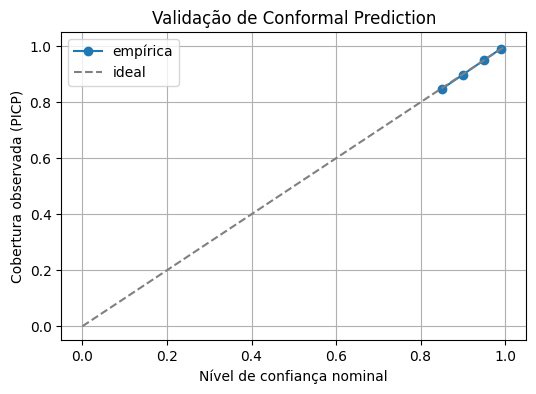


=== Métricas do modelo (ponto estimado) ===
RMSE: 341.1490    R²: 0.9901    Adj R²: 0.9901
MAE: 198.7818    MdAE: 98.2000    MAPE: 6.45%
MSLE: 0.0078    ExplainedVar: 0.9901


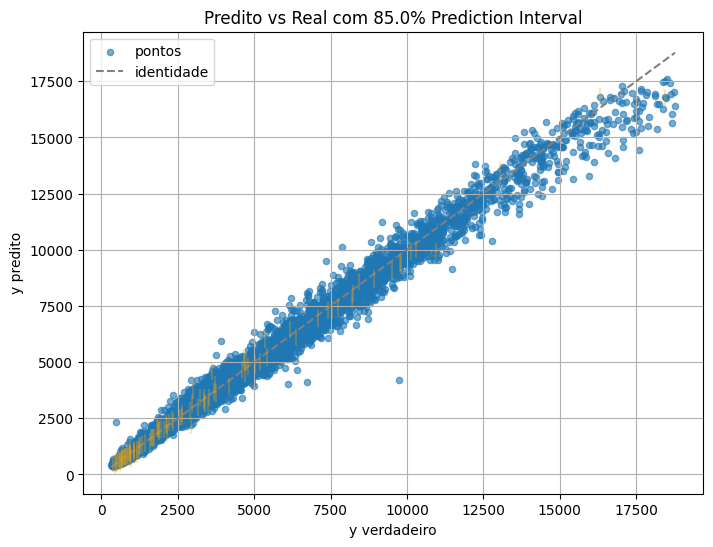

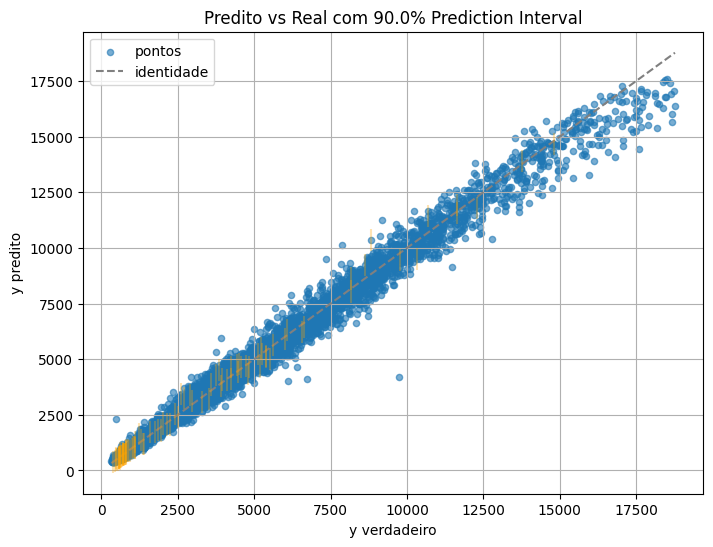

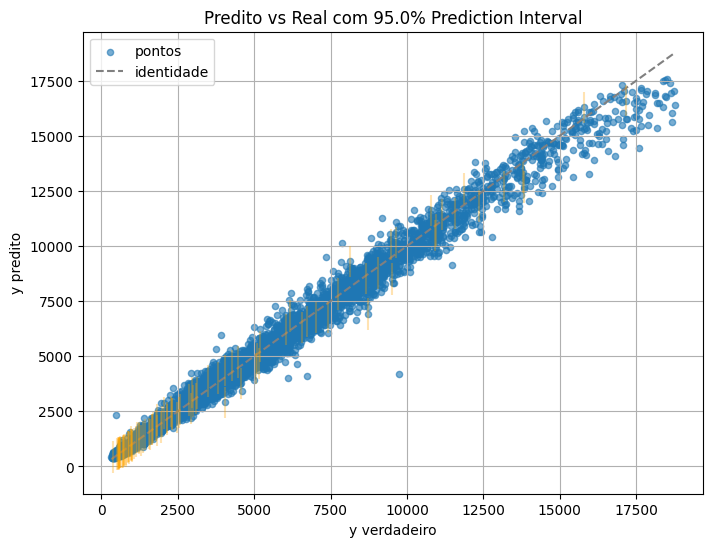

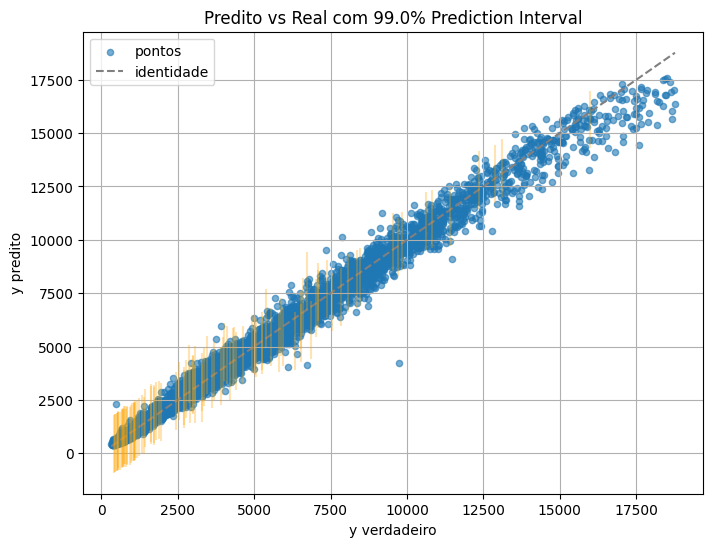


Tempo total de processamento: 1022.60 segundos


In [48]:

# 1) pré-compute predições e residuals na CALIBRAÇÃO
y_calib_pred = pipeline_model.predict(X_calib)
residuals    = np.abs(y_calib - y_calib_pred)

# 2) predições no TESTE (só uma vez!)
y_test_pred = pipeline_model.predict(X_test)

# 3) defina os níveis de confiança que quer checar
alphas = [0.15, 0.10, 0.05, 0.01]  # para 85%, 90%, 95%, 99% de “coverage”

# 4) rodar para cada α, mas sem refazer predict() ou métricas comuns
results = []
n = len(y_test)
for alpha in alphas:
    q      = np.quantile(residuals, 1 - alpha)  # conformal score
    lower  = y_test_pred - q
    upper  = y_test_pred + q

    # cobertura empírica
    inside = (y_test >= lower) & (y_test <= upper)
    picp   = inside.mean()        # PICP = % realmente dentro do intervalo
    mpiw   = np.mean(upper - lower)  # MPIW = largura média do intervalo

    results.append({
        "alpha": alpha,
        "conf_level": 1 - alpha,
        "PICP": picp,
        "MPIW": mpiw,
    })

# 5) concatena num DataFrame e plota cobertura vs nominal
df_cov = pd.DataFrame(results)

print("\n=== Cobertura dos Intervalos ===")
# display(df_cov.set_index("conf_level").round(4))

plt.figure(figsize=(6,4))
plt.plot(df_cov["conf_level"], df_cov["PICP"], "o-", label="empírica")
plt.plot([0,1],[0,1],"--", color="gray", label="ideal")
plt.xlabel("Nível de confiança nominal")
plt.ylabel("Cobertura observada (PICP)")
plt.title("Validação de Conformal Prediction")
plt.legend()
plt.grid(True)
plt.show()

# 6) Métricas pontuais do modelo (não dependem de α)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2   = r2_score(y_test, y_test_pred)
mae  = mean_absolute_error(y_test, y_test_pred)
mdae = median_absolute_error(y_test, y_test_pred)
msle = mean_squared_log_error(y_test, y_test_pred)
evs  = explained_variance_score(y_test, y_test_pred)
n, p = n, X_test.shape[1]
adj_r2 = 1 - (1 - r2)*(n-1)/(n-p-1)
mape   = np.mean(np.abs((y_test - y_test_pred)/y_test))*100

print("\n=== Métricas do modelo (ponto estimado) ===")
print(f"RMSE: {rmse:.4f}    R²: {r2:.4f}    Adj R²: {adj_r2:.4f}")
print(f"MAE: {mae:.4f}    MdAE: {mdae:.4f}    MAPE: {mape:.2f}%")
print(f"MSLE: {msle:.4f}    ExplainedVar: {evs:.4f}")

# 7) Gráfico final: verdade vs predito + 95% PI (exemplo)
for alpha in alphas:
    q     = np.quantile(residuals, 1 - alpha)
    lower = y_test_pred - q
    upper = y_test_pred + q

    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_test_pred, s=20, alpha=0.6, label="pontos")
    plt.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            "--", color="gray", label="identidade")
    # barras verticais para alguns pontos aleatórios
    idx = np.random.choice(n, size=100, replace=False)
    y_true = y_test.to_numpy()      # ou y_test.values
    lower  = np.asarray(lower)
    upper  = np.asarray(upper)

    for i in idx:
        plt.vlines(y_true[i], lower[i], upper[i],
                color="orange", alpha=0.3)

    plt.xlabel("y verdadeiro")
    plt.ylabel("y predito")
    plt.title(f"Predito vs Real com {(1-alpha)*100}% Prediction Interval")
    plt.legend()
    plt.grid(True)
    plt.show()

# Finaliza a medição do tempo
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTempo total de processamento: {elapsed_time:.2f} segundos")



